# Q3 — Evaluation and Analysis
**Author:** Muhammad Khalid (URN: 6958235)

This notebook evaluates all models built by the group for Sentiment Analysis and Sarcasm Detection across three English varieties (en-AU,en-IN, en-UK).

**What this notebook covers:**
- Baseline TF-IDF + Logistic Regression model (built and evaluated here)
- Evaluation of Q2.1 classical models and RoBERTa (predictions loaded from teammate's notebook)
- Summary of Q2.2 Cross-Variety evaluation results
- Summary of Q2.3 LoRA adapter results
- Per-variety Macro-F1, Precision, Recall, and Confusion Matrices for all models

**Prediction files required:** preds2_LR_sarcasm.npy, preds2_SVM_sarcasm.npy,
preds2_RoBERTa_run1_sarcasm.npy, preds2_RoBERTa_run2_sarcasm.npy
(Generated from Aiyoun Khan Anady's Q2 notebook)

In [1]:
from datasets import load_dataset
ds = load_dataset("surrey-nlp/BESSTIE-CW-26")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

In [2]:
import pandas as pd

# Convert train split to a pandas DataFrame so it's easier to look at
train_df = pd.DataFrame(ds['train'])

# See the first 5 rows
train_df.head()

,text,variety,source,Sentiment,Sarcasm
0,I'm a member of the Green Party but I'll be vo...,en-UK,Reddit,0.0,0.0
1,Yeah it blew out to 3x what it was budgeted fo...,en-AU,Reddit,0.0,1.0
2,"Food was pretty great. A little dry, but I am ...",en-AU,Google,1.0,0.0
3,Firstly the staff seemed as if they did n't wa...,en-UK,Google,0.0,0.0
4,We came for lunch and enjoyed the food we orde...,en-UK,Google,1.0,0.0


In [3]:
# See what columns exist and how many rows
print(train_df.shape)
print(train_df.columns.tolist())

(3747, 5)
['text', 'variety', 'source', 'Sentiment', 'Sarcasm']


In [4]:
# How many examples per variety?
print("=== Variety counts ===")
print(train_df['variety'].value_counts())

print("\n=== Source counts ===")
print(train_df['source'].value_counts())

print("\n=== Sentiment distribution ===")
print(train_df['Sentiment'].value_counts())

print("\n=== Sarcasm distribution ===")
print(train_df['Sarcasm'].value_counts())

=== Variety counts ===
variety
en-IN    1399
en-UK    1203
en-AU    1145
Name: count, dtype: int64

=== Source counts ===
source
Google    1874
Reddit    1873
Name: count, dtype: int64

=== Sentiment distribution ===
Sentiment
0.0    1907
1.0    1840
Name: count, dtype: int64

=== Sarcasm distribution ===
Sarcasm
0.0    3223
1.0     524
Name: count, dtype: int64


In [5]:
# Sentiment and Sarcasm distribution PER variety
print("=== Sentiment by variety ===")
print(train_df.groupby('variety')['Sentiment'].value_counts())

print("\n=== Sarcasm by variety ===")
print(train_df.groupby('variety')['Sarcasm'].value_counts())

=== Sentiment by variety ===
variety  Sentiment
en-AU    0.0          633
         1.0          512
en-IN    1.0          710
         0.0          689
en-UK    1.0          618
         0.0          585
Name: count, dtype: int64

=== Sarcasm by variety ===
variety  Sarcasm
en-AU    0.0         808
         1.0         337
en-IN    0.0        1304
         1.0          95
en-UK    0.0        1111
         1.0          92
Name: count, dtype: int64


In [6]:
val_df = pd.DataFrame(ds['validation'])
test_df = pd.DataFrame(ds['test'])

print("=== Split sizes ===")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

print("\n=== Sarcasm by variety (Validation) ===")
print(val_df.groupby('variety')['Sarcasm'].value_counts())

print("\n=== Sarcasm by variety (Test) ===")
print(test_df.groupby('variety')['Sarcasm'].value_counts())

=== Split sizes ===
Train: 3747, Val: 313, Test: 2183

=== Sarcasm by variety (Validation) ===
variety  Sarcasm
en-AU    0.0         67
         1.0         28
en-IN    0.0        109
         1.0          8
en-UK    0.0         93
         1.0          8
Name: count, dtype: int64

=== Sarcasm by variety (Test) ===
variety  Sarcasm
en-AU    0.0        471
         1.0        196
en-IN    0.0        760
         1.0         56
en-UK    0.0        647
         1.0         53
Name: count, dtype: int64


## Baseline Model
Training a simple TF-IDF + Logistic Regression model first to see how well a basic approach works on sentiment and sarcasm. This gives us something to compare the fancier models against.

In [7]:
# Step 1: Prepare the data
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Sentiment classification first
X_train = train_df['text']
y_train = train_df['Sentiment']

X_test = test_df['text']
y_test = test_df['Sentiment']

# Step 2: Convert text to numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Step 3: Train a simple model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Step 4: Make predictions
y_pred = model.predict(X_test_tfidf)

# Step 5: See how it did
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

precision    recall  f1-score   support

    Negative       0.81      0.87      0.84      1117
    Positive       0.86      0.79      0.82      1066

    accuracy                           0.83      2183
   macro avg       0.84      0.83      0.83      2183
weighted avg       0.83      0.83      0.83      2183


In [8]:
# Performance broken down by variety
for variety in ['en-AU', 'en-IN', 'en-UK']:
    mask = test_df['variety'] == variety
    y_true_v = y_test[mask]
    y_pred_v = y_pred[mask]
    print(f"\n=== {variety} - Sentiment ===")
    print(classification_report(y_true_v, y_pred_v, target_names=['Negative', 'Positive']))

=== en-AU - Sentiment ===
              precision    recall  f1-score   support

    Negative       0.77      0.93      0.84       347
    Positive       0.90      0.69      0.78       320

    accuracy                           0.82       667
   macro avg       0.83      0.81      0.81       667
weighted avg       0.83      0.82      0.81       667


=== en-IN - Sentiment ===
              precision    recall  f1-score   support

    Negative       0.79      0.84      0.82       430
    Positive       0.81      0.76      0.78       386

    accuracy                           0.80       816
   macro avg       0.80      0.80      0.80       816
weighted avg       0.80      0.80      0.80       816


=== en-UK - Sentiment ===
              precision    recall  f1-score   support

    Negative       0.90      0.87      0.88       340
    Positive       0.88      0.91      0.89       360

    accuracy                           0.89       700
   macro avg       0.89      0.89      0.89     

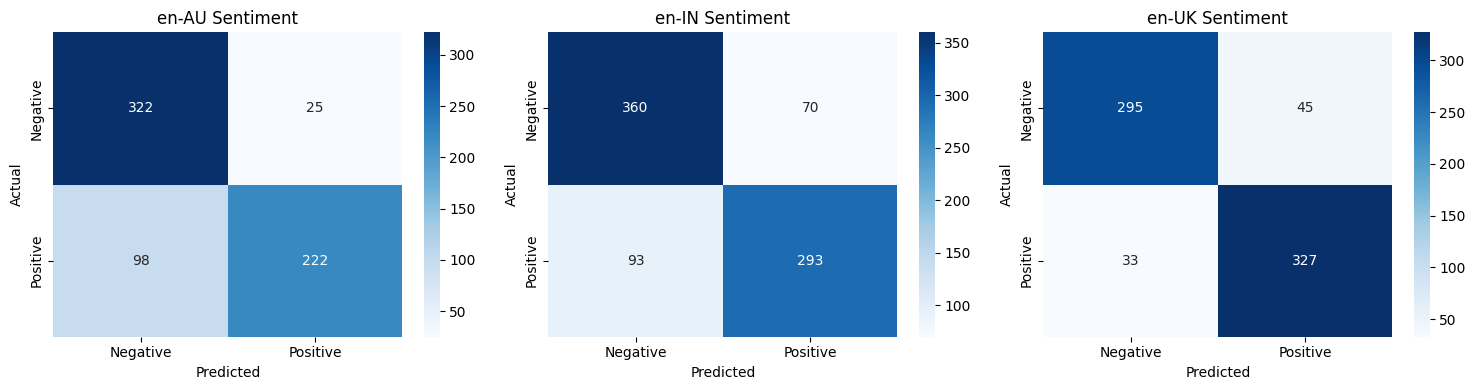

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, variety in enumerate(['en-AU', 'en-IN', 'en-UK']):
    mask = test_df['variety'] == variety
    cm = confusion_matrix(y_test[mask], y_pred[mask])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[i].set_title(f'{variety} Sentiment')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [10]:
# Now train a sarcasm model
X_train_sarc = train_df['text']
y_train_sarc = train_df['Sarcasm']

X_test_sarc = test_df['text']
y_test_sarc = test_df['Sarcasm']

# Reuse same TF-IDF features
tfidf_sarc = TfidfVectorizer(max_features=5000)
X_train_sarc_tfidf = tfidf_sarc.fit_transform(X_train_sarc)
X_test_sarc_tfidf = tfidf_sarc.transform(X_test_sarc)

# Train with class_weight='balanced' to handle imbalance
model_sarc = LogisticRegression(max_iter=1000, class_weight='balanced')
model_sarc.fit(X_train_sarc_tfidf, y_train_sarc)

# Predict
y_pred_sarc = model_sarc.predict(X_test_sarc_tfidf)

# Overall results
print("=== Overall Sarcasm Results ===")
print(classification_report(y_test_sarc, y_pred_sarc, target_names=['Not Sarcastic', 'Sarcastic']))

=== Overall Sarcasm Results ===
               precision    recall  f1-score   support

Not Sarcastic       0.93      0.77      0.84      1878
    Sarcastic       0.31      0.66      0.43       305

     accuracy                           0.75      2183
    macro avg       0.62      0.71      0.63      2183
 weighted avg       0.85      0.75      0.78      2183


=== en-AU - Sarcasm ===
               precision    recall  f1-score   support

Not Sarcastic       0.84      0.73      0.78       471
    Sarcastic       0.51      0.67      0.58       196

     accuracy                           0.71       667
    macro avg       0.68      0.70      0.68       667
 weighted avg       0.74      0.71      0.72       667


=== en-IN - Sarcasm ===
               precision    recall  f1-score   support

Not Sarcastic       0.97      0.76      0.86       760
    Sarcastic       0.18      0.70      0.28        56

     accuracy                           0.76       816
    macro avg       0.58      0.73      0.57       816
 weighted avg       0.92      0.76      0.82       816


=== en-UK - Sarcasm ===
               precision    recall  f1-score   support

Not Sarcastic       0.96      0.79      0.87       647
    Sarcastic       0.19      0.58      0.29        53

     accuracy                           0.78       700
    macro avg       0.57      0.69    

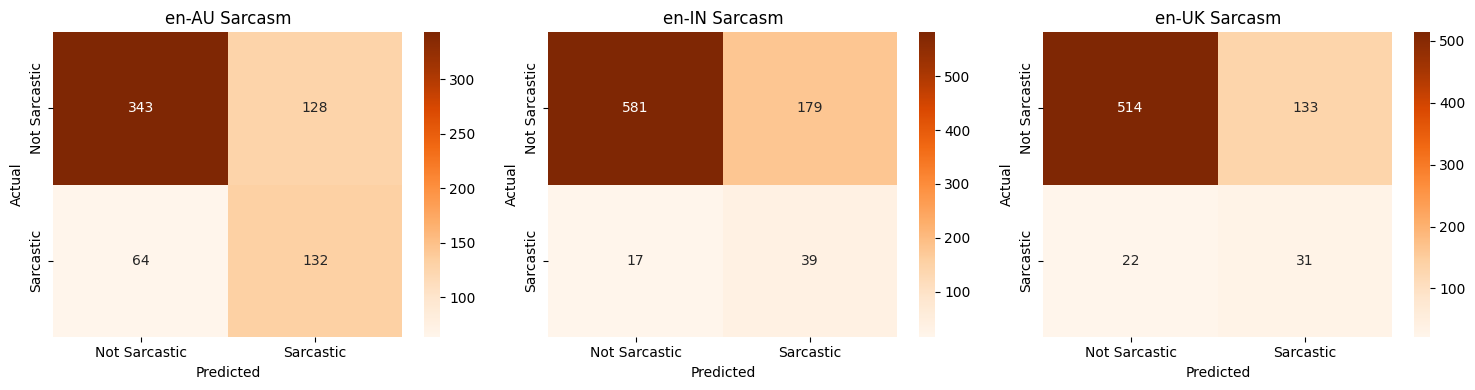

In [11]:
# Per-variety sarcasm results
for variety in ['en-AU', 'en-IN', 'en-UK']:
    mask = test_df['variety'] == variety
    y_true_v = y_test_sarc[mask]
    y_pred_v = y_pred_sarc[mask]
    print(f"\n=== {variety} - Sarcasm ===")
    print(classification_report(y_true_v, y_pred_v, target_names=['Not Sarcastic', 'Sarcastic'], zero_division=0))

# Confusion matrices for sarcasm
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, variety in enumerate(['en-AU', 'en-IN', 'en-UK']):
    mask = test_df['variety'] == variety
    cm = confusion_matrix(y_test_sarc[mask], y_pred_sarc[mask])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[i],
                xticklabels=['Not Sarcastic', 'Sarcastic'],
                yticklabels=['Not Sarcastic', 'Sarcastic'])
    axes[i].set_title(f'{variety} Sarcasm')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [12]:
# Create a clean summary table of all results
from sklearn.metrics import f1_score, precision_score, recall_score

results = []

# Sentiment evaluation per variety
for variety in ['en-AU', 'en-IN', 'en-UK', 'Overall']:
    if variety == 'Overall':
        mask = [True] * len(test_df)
    else:
        mask = test_df['variety'] == variety

    # Sentiment
    p = precision_score(y_test[mask], y_pred[mask], average='macro')
    r = recall_score(y_test[mask], y_pred[mask], average='macro')
    f1 = f1_score(y_test[mask], y_pred[mask], average='macro')
    results.append({'Task': 'Sentiment', 'Variety': variety,
                    'Precision': round(p,3), 'Recall': round(r,3), 'Macro-F1': round(f1,3)})

    # Sarcasm
    p = precision_score(y_test_sarc[mask], y_pred_sarc[mask], average='macro')
    r = recall_score(y_test_sarc[mask], y_pred_sarc[mask], average='macro')
    f1 = f1_score(y_test_sarc[mask], y_pred_sarc[mask], average='macro')
    results.append({'Task': 'Sarcasm', 'Variety': variety,
                    'Precision': round(p,3), 'Recall': round(r,3), 'Macro-F1': round(f1,3)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Task Variety  Precision  Recall  Macro-F1
Sentiment   en-AU      0.833   0.811     0.811
  Sarcasm   en-AU      0.675   0.701     0.680
Sentiment   en-IN      0.801   0.798     0.799
  Sarcasm   en-IN      0.575   0.730     0.570
Sentiment   en-UK      0.889   0.888     0.888
  Sarcasm   en-UK      0.574   0.690     0.577
Sentiment Overall      0.835   0.832     0.833
  Sarcasm Overall      0.624   0.714     0.634


## Reusable Evaluation Function
Built this function so I can run the same evaluation on every model without repeating code. It gives me classification report, per-variety breakdown, and confusion matrices in one call.

In [13]:
# YOUR REUSABLE Q3 EVALUATION FUNCTION
# Use this for every model your teammates give you

def evaluate_model(y_true, y_pred, task_name, model_name, variety_col):
    """
    Evaluates any model's predictions and prints:
    - Summary table with Macro-F1, Precision, Recall per variety
    - Confusion matrices
    """
    from sklearn.metrics import (classification_report, confusion_matrix,
                                  f1_score, precision_score, recall_score)

    if task_name == 'Sentiment':
        labels = ['Negative', 'Positive']
    else:
        labels = ['Not Sarcastic', 'Sarcastic']

    # Overall report
    print(f"\n{'='*50}")
    print(f"MODEL: {model_name} | TASK: {task_name}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=labels))

    # Per-variety results
    results = []
    varieties = variety_col.unique()

    for variety in sorted(varieties):
        mask = variety_col == variety
        p = precision_score(y_true[mask], y_pred[mask], average='macro')
        r = recall_score(y_true[mask], y_pred[mask], average='macro')
        f1 = f1_score(y_true[mask], y_pred[mask], average='macro')
        results.append({'Variety': variety, 'Precision': round(p,3),
                       'Recall': round(r,3), 'Macro-F1': round(f1,3)})

    # Add overall
    p = precision_score(y_true, y_pred, average='macro')
    r = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    results.append({'Variety': 'Overall', 'Precision': round(p,3),
                   'Recall': round(r,3), 'Macro-F1': round(f1,3)})

    print(pd.DataFrame(results).to_string(index=False))

    # Confusion matrices
    fig, axes = plt.subplots(1, len(varieties), figsize=(5*len(varieties), 4))
    if len(varieties) == 1:
        axes = [axes]

    for i, variety in enumerate(sorted(varieties)):
        mask = variety_col == variety
        cm = confusion_matrix(y_true[mask], y_pred[mask])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if task_name=='Sentiment' else 'Oranges',
                    ax=axes[i], xticklabels=labels, yticklabels=labels)
        axes[i].set_title(f'{variety} {task_name}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    plt.suptitle(f'{model_name} - {task_name}', y=1.02)
    plt.tight_layout()
    plt.show()

print("Function ready! Use it like this:")
print("evaluate_model(y_true, y_pred, 'Sentiment', 'TF-IDF + LogReg', test_df['variety'])")

Function ready! Use it like this:
evaluate_model(y_true, y_pred, 'Sentiment', 'TF-IDF + LogReg', test_df['variety'])


MODEL: TF-IDF + LogReg | TASK: Sentiment
              precision    recall  f1-score   support

    Negative       0.81      0.87      0.84      1117
    Positive       0.86      0.79      0.82      1066

    accuracy                           0.83      2183
   macro avg       0.84      0.83      0.83      2183
weighted avg       0.83      0.83      0.83      2183

Variety  Precision  Recall  Macro-F1
  en-AU      0.833   0.811     0.811
  en-IN      0.801   0.798     0.799
  en-UK      0.889   0.888     0.888
Overall      0.835   0.832     0.833


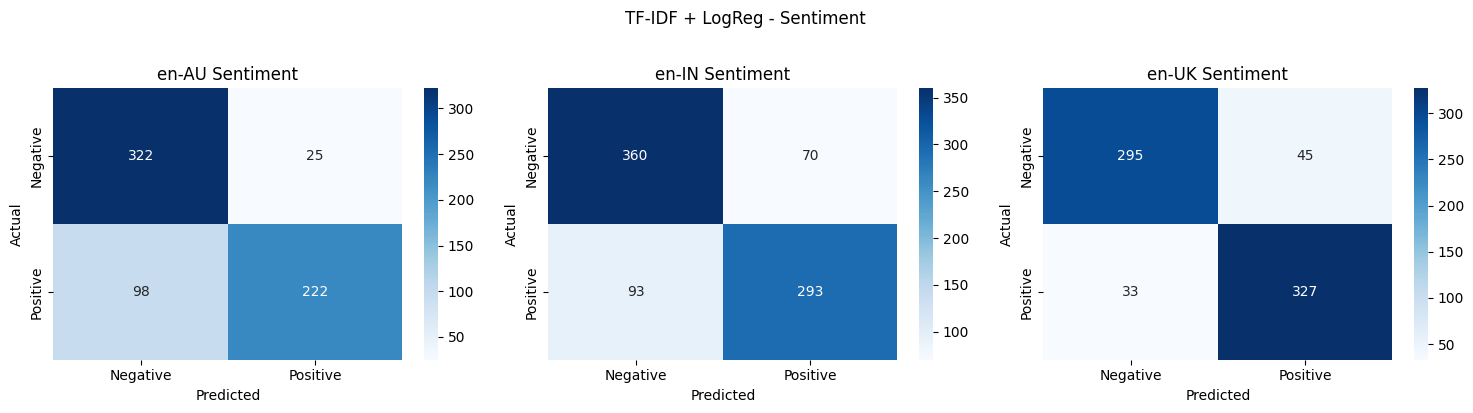

MODEL: TF-IDF + LogReg | TASK: Sarcasm
               precision    recall  f1-score   support

Not Sarcastic       0.93      0.77      0.84      1878
    Sarcastic       0.31      0.66      0.43       305

     accuracy                           0.75      2183
    macro avg       0.62      0.71      0.63      2183
 weighted avg       0.85      0.75      0.78      2183

Variety  Precision  Recall  Macro-F1
  en-AU      0.675   0.701     0.680
  en-IN      0.575   0.730     0.570
  en-UK      0.574   0.690     0.577
Overall      0.624   0.714     0.634


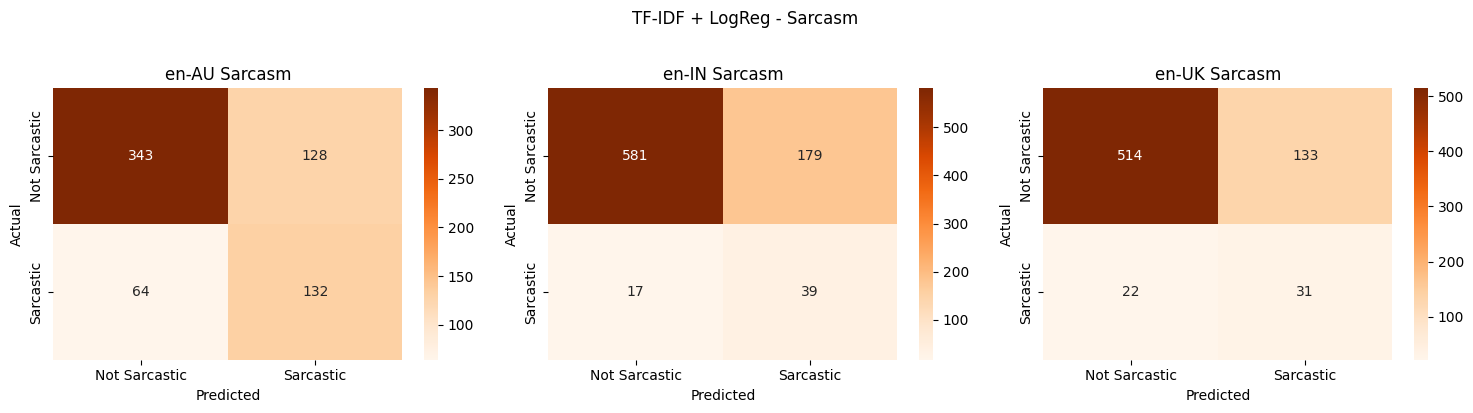

In [14]:
# Test the function with your baseline results
evaluate_model(y_test, y_pred, 'Sentiment', 'TF-IDF + LogReg', test_df['variety'])
evaluate_model(y_test_sarc, y_pred_sarc, 'Sarcasm', 'TF-IDF + LogReg', test_df['variety'])

## Evaluating Q2.1 Models (RoBERTa + Classical)
Loading predictions from Aiyoun's notebook. These are sarcasm predictions from LR, SVM, and two RoBERTa runs on the full test set.

In [27]:
import numpy as np

preds2_LR = np.load('preds2_LR_sarcasm.npy')
preds2_SVM = np.load('preds2_SVM_sarcasm.npy')
preds2_RoBERTa_r1 = np.load('preds2_RoBERTa_run1_sarcasm.npy')
preds2_RoBERTa_r2 = np.load('preds2_RoBERTa_run2_sarcasm.npy')

print("All 4 files loaded!")
print(f"Shapes: LR={preds2_LR.shape}, SVM={preds2_SVM.shape}, RoBERTa R1={preds2_RoBERTa_r1.shape}, RoBERTa R2={preds2_RoBERTa_r2.shape}")

All 4 files loaded!
Shapes: LR=(2183,), SVM=(2183,), RoBERTa R1=(2183,), RoBERTa R2=(2183,)


## Final Summary Tables
Pulling everything together — all models compared side by side. Cross-variety and LoRA scores are taken directly from the Q2.2 and Q2.3 notebooks since those experiments output per-variety F1 scores already.

MODEL: LR (ngram, class_weight) | TASK: Sarcasm
               precision    recall  f1-score   support

Not Sarcastic       0.92      0.79      0.85      1878
    Sarcastic       0.31      0.59      0.41       305

     accuracy                           0.76      2183
    macro avg       0.62      0.69      0.63      2183
 weighted avg       0.84      0.76      0.79      2183

Variety  Precision  Recall  Macro-F1
  en-AU      0.673   0.688     0.678
  en-IN      0.552   0.644     0.546
  en-UK      0.581   0.698     0.590
Overall      0.617   0.689     0.629


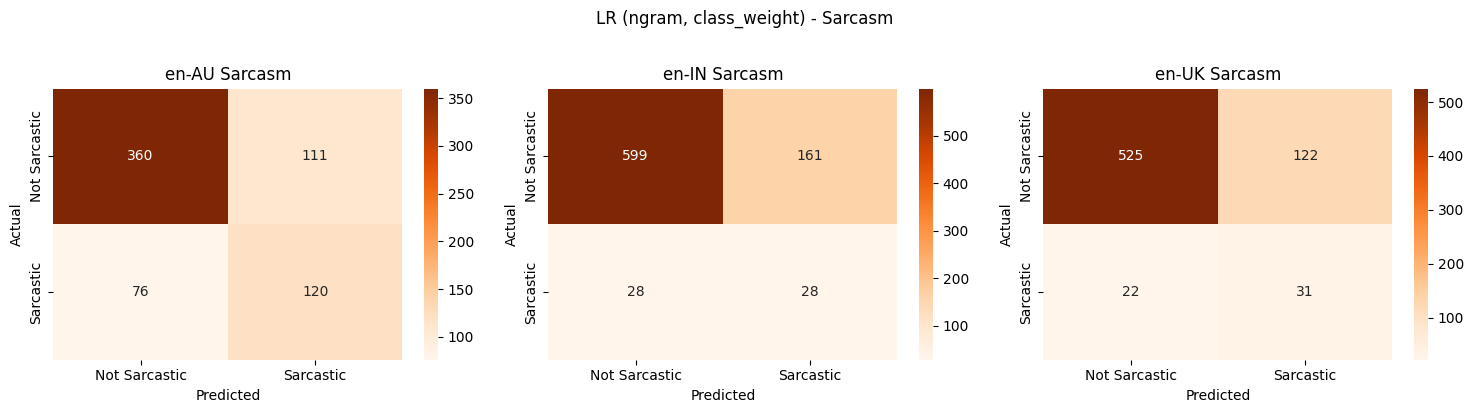

MODEL: LinearSVC (class_weight) | TASK: Sarcasm
               precision    recall  f1-score   support

Not Sarcastic       0.89      0.89      0.89      1878
    Sarcastic       0.32      0.32      0.32       305

     accuracy                           0.81      2183
    macro avg       0.60      0.60      0.60      2183
 weighted avg       0.81      0.81      0.81      2183

Variety  Precision  Recall  Macro-F1
  en-AU      0.627   0.592     0.597
  en-IN      0.545   0.577     0.552
  en-UK      0.597   0.642     0.612
Overall      0.603   0.603     0.603


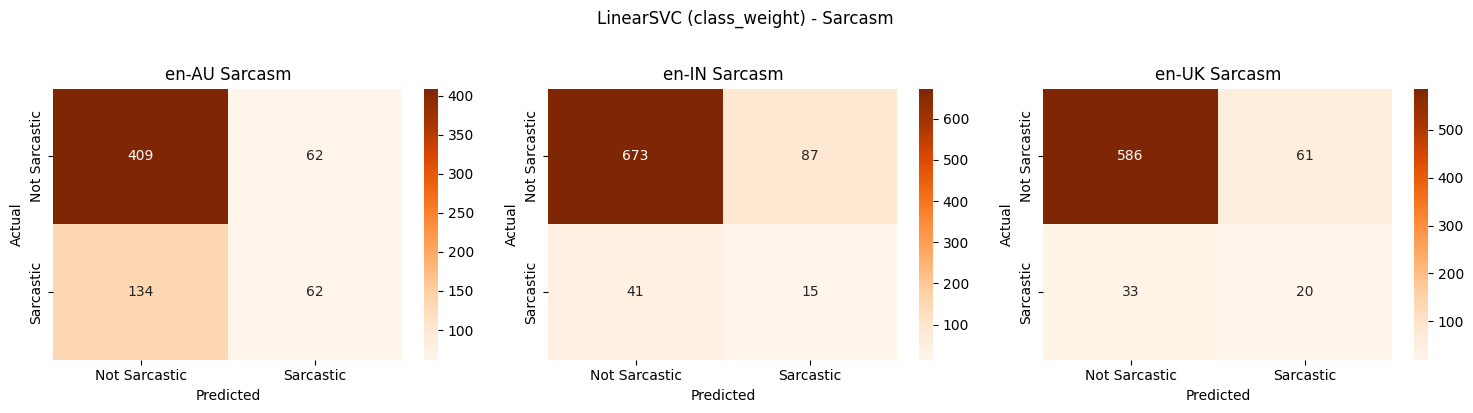

MODEL: RoBERTa Run 1 | TASK: Sarcasm
               precision    recall  f1-score   support

Not Sarcastic       0.90      0.96      0.93      1878
    Sarcastic       0.57      0.33      0.42       305

     accuracy                           0.87      2183
    macro avg       0.73      0.65      0.67      2183
 weighted avg       0.85      0.87      0.86      2183

Variety  Precision  Recall  Macro-F1
  en-AU      0.782   0.656     0.673
  en-IN      0.581   0.566     0.573
  en-UK      0.727   0.699     0.712
Overall      0.734   0.647     0.675


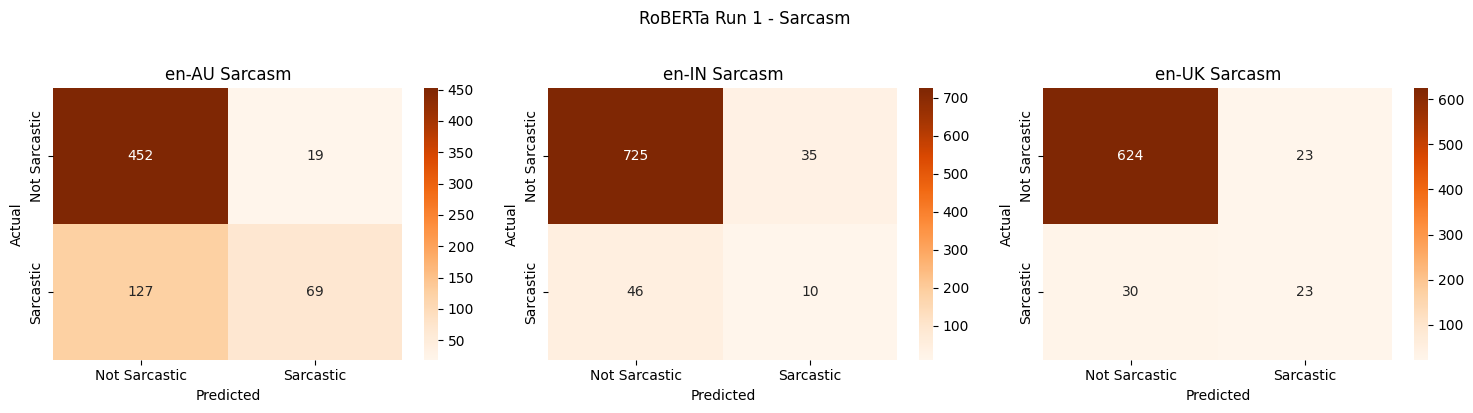

MODEL: RoBERTa Run 2 | TASK: Sarcasm
               precision    recall  f1-score   support

Not Sarcastic       0.89      0.98      0.93      1878
    Sarcastic       0.60      0.22      0.32       305

     accuracy                           0.87      2183
    macro avg       0.74      0.60      0.63      2183
 weighted avg       0.85      0.87      0.84      2183

Variety  Precision  Recall  Macro-F1
  en-AU      0.741   0.628     0.638
  en-IN      0.567   0.519     0.521
  en-UK      0.632   0.539     0.552
Overall      0.741   0.599     0.626


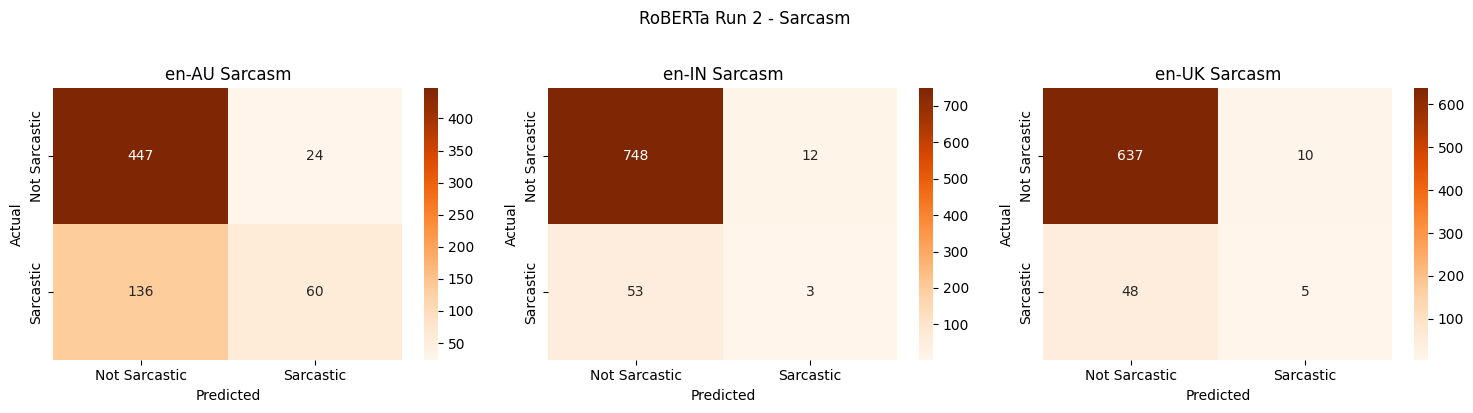

In [28]:
# Evaluate RoBERTa and classical models from Aiyoun's second notebook
# These are all SARCASM predictions

evaluate_model(y_test_sarc, preds2_LR, 'Sarcasm', 'LR (ngram, class_weight)', test_df['variety'])
evaluate_model(y_test_sarc, preds2_SVM, 'Sarcasm', 'LinearSVC (class_weight)', test_df['variety'])
evaluate_model(y_test_sarc, preds2_RoBERTa_r1, 'Sarcasm', 'RoBERTa Run 1', test_df['variety'])
evaluate_model(y_test_sarc, preds2_RoBERTa_r2, 'Sarcasm', 'RoBERTa Run 2', test_df['variety'])

In [29]:
# COMPLETE Q3 SUMMARY TABLE
from sklearn.metrics import f1_score

def get_f1(y_true, y_pred, variety_col, variety=None):
    if variety is None:
        return f1_score(y_true, y_pred, average='macro')
    mask = variety_col == variety
    return f1_score(y_true[mask], y_pred[mask], average='macro')

# All sarcasm models that have been evaluated
all_sarcasm_models = {
    'TF-IDF + LR (baseline)': y_pred_sarc,
    'LR (ngram, CW)': preds2_LR,
    'LinearSVC (CW)': preds2_SVM,
    'RoBERTa Run 1': preds2_RoBERTa_r1,
    'RoBERTa Run 2': preds2_RoBERTa_r2,
}

print("=" * 65)
print("SARCASM — All Models Macro-F1 Comparison")
print("=" * 65)
rows = []
for name, pred in all_sarcasm_models.items():
    rows.append({
        'Model': name,
        'en-AU': round(get_f1(y_test_sarc, pred, test_df['variety'], 'en-AU'), 3),
        'en-IN': round(get_f1(y_test_sarc, pred, test_df['variety'], 'en-IN'), 3),
        'en-UK': round(get_f1(y_test_sarc, pred, test_df['variety'], 'en-UK'), 3),
        'Overall': round(get_f1(y_test_sarc, pred, test_df['variety']), 3)
    })
print(pd.DataFrame(rows).to_string(index=False))

# Cross-variety results (from Aiyoun's notebook - already computed)
print("\n" + "=" * 65)
print("CROSS-VARIETY EVALUATION (RoBERTa, Sarcasm) — Macro-F1")
print("=" * 65)
cross_var = {
    'Train en-AU': {'en-AU': 0.6932, 'en-IN': 0.5527, 'en-UK': 0.6542},
    'Train en-IN': {'en-AU': 0.4139, 'en-IN': 0.4982, 'en-UK': 0.4803},
    'Train en-UK': {'en-AU': 0.4188, 'en-IN': 0.4822, 'en-UK': 0.4803},
}
cv_rows = []
for name, scores in cross_var.items():
    cv_rows.append({'Model': name, **scores})
print(pd.DataFrame(cv_rows).to_string(index=False))

# LoRA results (from Aiyoun's notebook - already computed)
print("\n" + "=" * 65)
print("LoRA ADAPTERS (TinyLlama 1.1B, Sarcasm) — Macro-F1")
print("=" * 65)
lora_var = {
    'LoRA en-AU': {'en-AU': 0.7373, 'en-IN': 0.5482, 'en-UK': 0.6001},
    'LoRA en-IN': {'en-AU': 0.4310, 'en-IN': 0.6128, 'en-UK': 0.5655},
    'LoRA en-UK': {'en-AU': 0.5359, 'en-IN': 0.6117, 'en-UK': 0.7145},
}
lora_rows = []
for name, scores in lora_var.items():
    lora_rows.append({'Model': name, **scores})
print(pd.DataFrame(lora_rows).to_string(index=False))

SARCASM — All Models Macro-F1 Comparison
                 Model  en-AU  en-IN  en-UK  Overall
TF-IDF + LR (baseline)  0.680  0.570  0.577    0.634
        LR (ngram, CW)  0.678  0.546  0.590    0.629
        LinearSVC (CW)  0.597  0.552  0.612    0.603
         RoBERTa Run 1  0.673  0.573  0.712    0.675
         RoBERTa Run 2  0.638  0.521  0.552    0.626

CROSS-VARIETY EVALUATION (RoBERTa, Sarcasm) — Macro-F1
      Model  en-AU  en-IN  en-UK
Train en-AU 0.6932 0.5527 0.6542
Train en-IN 0.4139 0.4982 0.4803
Train en-UK 0.4188 0.4822 0.4803

LoRA ADAPTERS (TinyLlama 1.1B, Sarcasm) — Macro-F1
     Model  en-AU  en-IN  en-UK
LoRA en-AU 0.7373 0.5482 0.6001
LoRA en-IN 0.4310 0.6128 0.5655
LoRA en-UK 0.5359 0.6117 0.7145
